# Data prep

In [1]:
from pathlib import Path

import contextily as cx
import geopandas
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas
import rasterio

from rasterio.mask import mask as rio_mask
from shapely.geometry import box, mapping


## Embeddings

In [2]:
emb20 = geopandas.read_file('uk_lsoa_london_embeds_2020.geojson')
emb24 = geopandas.read_file('uk_lsoa_london_embeds_2024.geojson')

- Pull out geometries and LSOA codes

In [3]:
lsoas = emb20[['LSOA21CD', 'geometry']]

## Landsat

This section adapts the workshop notebook `w07_pixelsToPatterns` to the `satIMD` workflow. We use two **Level-2 Surface Reflectance** Landsat scenes stored inside this project:

- **2019:** Landsat 8 (`LC08`) scene acquired on **2019-08-26**
- **2025:** Landsat 9 (`LC09`) scene acquired on **2025-08-11**

Both products include:

- `SR_B1` to `SR_B7`: optical surface-reflectance bands
- `QA_*`: quality masks
- `ST_*`: surface-temperature layers

For the notebook we focus on **surface reflectance bands 1-7**, because they are directly comparable across years and they are enough for RGB composites and NDVI.

Landsat scenes cover a much larger area than London, so our first step is to inspect the scenes, compare their footprint against the London study area, and then crop and mask them to the LSOA boundary used elsewhere in the notebook.


In [ ]:
def resolve_repo_root() -> Path:
    candidates = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
    for candidate in candidates:
        if (candidate / "data" / "landsat").exists() and (candidate / "jupyterlite").exists():
            return candidate
    raise FileNotFoundError("Could not locate the satIMD repository root from the current working directory.")


REPO_ROOT = resolve_repo_root()
LANDSAT_ROOT = REPO_ROOT / "data" / "landsat"
LANDSAT_SCENES = {
    "2019": LANDSAT_ROOT / "2019",
    "2025": LANDSAT_ROOT / "2025",
}

print(f"Repository root: {REPO_ROOT}")
for year, scene_dir in LANDSAT_SCENES.items():
    print(f"{year}: {scene_dir}")


### Scene inventory

Before loading any rasters, it helps to inspect what each archive contains. This also makes the workflow robust if a scene is missing one of the optical bands.

In Landsat Collection 2, the key file groups are:

- `SR_B*`: optical surface reflectance
- `QA_*`: quality assessment layers
- `ST_*`: land surface temperature products

For this workshop workflow, the optical surface-reflectance bands are the main input.


In [ ]:
def scene_inventory(scene_dir: Path, year: str) -> pandas.DataFrame:
    scene_files = sorted(scene_dir.glob("*.TIF"))
    rows = []
    for tif in scene_files:
        suffix = tif.stem.split("_")[-1]
        rows.append({
            "year": year,
            "file": tif.name,
            "layer": suffix,
            "kind": (
                "surface_reflectance" if "_SR_B" in tif.stem else
                "qa" if "QA" in tif.stem else
                "surface_temperature" if "_ST_" in tif.stem else
                "other"
            )
        })
    return pandas.DataFrame(rows)


landsat_inventory = pandas.concat(
    [scene_inventory(scene_dir, year) for year, scene_dir in LANDSAT_SCENES.items()],
    ignore_index=True
)

landsat_inventory.groupby(["year", "kind"]).size()


## Raster Properties & Loading Bands

Landsat 8 and Landsat 9 carry two sensors: the **Operational Land Imager (OLI)** and the **Thermal Infrared Sensor (TIRS)**. Together they provide 11 spectral bands.

| Band | Name | Wavelength | Resolution | What it is good for |
|------|------|-----------|------------|---------------------|
| 1 | Ultra Blue (Coastal/Aerosol) | 0.43-0.45 um | **30 m** | Coastal water, haze, aerosol studies |
| 2 | Blue | 0.45-0.51 um | **30 m** | Water depth, soil and vegetation distinction |
| 3 | Green | 0.53-0.59 um | **30 m** | Peak vegetation reflectance |
| 4 | Red | 0.64-0.67 um | **30 m** | Chlorophyll absorption, vegetation versus bare soil |
| 5 | Near Infrared (NIR) | 0.85-0.88 um | **30 m** | Biomass, vegetation health, water boundaries |
| 6 | SWIR-1 | 1.57-1.65 um | **30 m** | Soil moisture, snow and cloud separation |
| 7 | SWIR-2 | 2.11-2.29 um | **30 m** | Geology, burn scars, dry surfaces |
| 8 | Panchromatic | 0.50-0.68 um | **15 m** | Higher-resolution greyscale detail |
| 9 | Cirrus | 1.36-1.38 um | **30 m** | High-altitude cirrus cloud detection |
| 10 | Thermal Infrared (TIRS-1) | 10.6-11.19 um | **100 m** | Surface temperature |
| 11 | Thermal Infrared (TIRS-2) | 11.50-12.51 um | **100 m** | Surface temperature, dual-band retrieval |

**What does 30 m resolution mean?** Each pixel covers a **30 x 30 metre** area on the ground. This is coarse relative to commercial imagery, but it is extremely useful for free, long-run environmental monitoring and cross-year comparison.

In this exercise we focus on **Bands 1-7**, which are the optical bands available at 30 m and are the ones we need for visualisation and NDVI.

In Python with `rasterio`, each band is loaded as a 2D `numpy` array, which means we can inspect, map, and transform the pixel values directly.


### Scene footprint and London boundary

We can compare the footprint of each scene with the London LSOA boundary already loaded in the notebook. This gives us a quick sense of how much of each image overlaps the study area before we crop and mask it.


In [ ]:
def first_surface_reflectance_band(scene_dir: Path) -> Path:
    matches = sorted(scene_dir.glob("*_SR_B1.TIF"))
    if not matches:
        raise FileNotFoundError(f"No SR_B1 file found in {scene_dir}")
    return matches[0]


footprints = []
for year, scene_dir in LANDSAT_SCENES.items():
    with rasterio.open(first_surface_reflectance_band(scene_dir)) as src:
        footprints.append({
            "year": year,
            "geometry": box(*src.bounds),
            "crs": src.crs,
            "resolution_m": src.res[0],
        })

scene_footprints = geopandas.GeoDataFrame(footprints, crs=footprints[0]["crs"]).drop(columns="crs")
london_outline = geopandas.GeoDataFrame(geometry=[lsoas.geometry.unary_union], crs=lsoas.crs).to_crs(scene_footprints.crs)

ax = scene_footprints.plot(figsize=(8, 8), facecolor="none", edgecolor=["#1f78b4", "#e31a1c"], linewidth=2)
london_outline.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1.2)
cx.add_basemap(ax, crs=scene_footprints.crs, source=cx.providers.CartoDB.Positron, alpha=0.5)
ax.set_title("Landsat scene footprints and London study area")
ax.set_axis_off()


### Crop and mask to London

The raw scenes cover much more than London. We therefore **crop** the raster to the study extent and **mask** it so that pixels outside the London LSOA boundary are removed.

This mirrors the logic in `w07_pixelsToPatterns`, but here we use the LSOA geometries already loaded in `satIMD` rather than downloading a separate workshop shapefile.

The cropped outputs are cached under `data/landsat/{year}/london/` so the notebook does not need to repeat the masking every time you rerun it.


In [ ]:
SURFACE_REFLECTANCE_SCALE = 0.0000275
SURFACE_REFLECTANCE_OFFSET = -0.2


def available_sr_bands(scene_dir: Path) -> dict[str, Path]:
    band_paths = {}
    for tif in sorted(scene_dir.glob("*_SR_B*.TIF")):
        band_name = tif.stem.split("_")[-1]
        if band_name.startswith("B") and band_name[1:].isdigit():
            band_paths[band_name] = tif
    return band_paths


def crop_and_mask_scene(scene_dir: Path, year: str, boundary: geopandas.GeoDataFrame) -> dict[str, Path]:
    out_dir = scene_dir / "london"
    out_dir.mkdir(parents=True, exist_ok=True)

    masked_paths = {}
    for band_name, tif_path in available_sr_bands(scene_dir).items():
        out_path = out_dir / tif_path.name.replace(".TIF", "_london.tif")
        masked_paths[band_name] = out_path

        if out_path.exists():
            continue

        with rasterio.open(tif_path) as src:
            boundary_in_raster_crs = boundary.to_crs(src.crs)
            geoms = [mapping(boundary_in_raster_crs.geometry.unary_union)]
            out_image, out_transform = rio_mask(src, geoms, crop=True)
            out_meta = src.meta.copy()

        out_meta.update({
            "driver": "GTiff",
            "height": out_image.shape[1],
            "width": out_image.shape[2],
            "transform": out_transform,
        })

        with rasterio.open(out_path, "w", **out_meta) as dst:
            dst.write(out_image)

    return masked_paths


cropped_band_paths = {
    year: crop_and_mask_scene(scene_dir, year, lsoas[["geometry"]])
    for year, scene_dir in LANDSAT_SCENES.items()
}

{year: sorted(paths.keys()) for year, paths in cropped_band_paths.items()}


### Load and scale the optical bands

The `SR_B*` layers are stored as scaled integers rather than ready-to-plot reflectance values. We therefore apply the standard Landsat Collection 2 scaling and offset before using them in maps or NDVI calculations.

At this stage we also replace `nodata` pixels with `NaN`, which makes later plotting and arithmetic much cleaner.


### Raster properties and individual bands

This part follows `w07_pixelsToPatterns` more literally: first inspect the raster metadata, then look at individual bands one by one.

The goal is not just to make a map, but to learn how different wavelengths respond to different surfaces. For example, vegetation often looks relatively dark in **Red (Band 4)** but much brighter in **NIR (Band 5)**.


In [ ]:
def read_surface_reflectance(path: Path) -> np.ndarray:
    with rasterio.open(path) as src:
        data = src.read(1).astype("float32")
        nodata = src.nodata
        if nodata is not None:
            data[data == nodata] = np.nan
    return (data * SURFACE_REFLECTANCE_SCALE + SURFACE_REFLECTANCE_OFFSET).astype("float32")


landsat_data = {}
for year, band_paths in cropped_band_paths.items():
    bands = {band_name: read_surface_reflectance(path) for band_name, path in band_paths.items()}
    required = {"B1", "B2", "B3", "B4", "B5", "B6", "B7"}
    missing = sorted(required.difference(bands))
    if missing:
        raise ValueError(f"{year} is missing required optical bands: {missing}")
    stack = np.stack([bands[band] for band in sorted(bands)], axis=0)
    first_band_path = band_paths["B1"]
    with rasterio.open(first_band_path) as src:
        metadata = {
            "shape": src.shape,
            "crs": src.crs,
            "resolution": src.res,
            "bounds": src.bounds,
        }
    landsat_data[year] = {
        "bands": bands,
        "stack": stack,
        "band_order": sorted(bands),
        "metadata": metadata,
    }

for year, payload in landsat_data.items():
    print(f"\n{year} optical bands: {payload['band_order']}")
    print(f"  Shape      : {payload['metadata']['shape']}")
    print(f"  CRS        : {payload['metadata']['crs']}")
    print(f"  Resolution : {payload['metadata']['resolution']} m")
    print(f"  Bounds     : {payload['metadata']['bounds']}")
    print(f"  Band 1 min/max: {np.nanmin(payload['bands']['B1']):.3f} / {np.nanmax(payload['bands']['B1']):.3f}")
    print(f"  Band 7 min/max: {np.nanmin(payload['bands']['B7']):.3f} / {np.nanmax(payload['bands']['B7']):.3f}")


In [ ]:
BAND_CMAPS = {
    "B1": ("Blues", "Band 1 — Ultra Blue / Coastal Aerosol"),
    "B7": ("YlOrBr", "Band 7 — SWIR-2"),
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for row, year in enumerate(["2019", "2025"]):
    for col, (band_name, (cmap, title)) in enumerate(BAND_CMAPS.items()):
        data = landsat_data[year]["bands"][band_name]
        vmin, vmax = np.nanpercentile(data, [2, 98])
        im = axes[row, col].imshow(data, cmap=cmap, vmin=vmin, vmax=vmax)
        axes[row, col].set_title(f"{year} {title}")
        axes[row, col].set_axis_off()
        fig.colorbar(im, ax=axes[row, col], fraction=0.03, pad=0.04, label="Reflectance")

plt.tight_layout()
plt.show()


In [ ]:
BAND_GRID = {
    "B2": ("Blues", "Band 2 — Blue"),
    "B3": ("Greens", "Band 3 — Green"),
    "B4": ("Reds", "Band 4 — Red"),
    "B5": ("RdYlGn", "Band 5 — NIR"),
}

for year in ["2019", "2025"]:
    fig, axes = plt.subplots(2, 2, figsize=(13, 11))
    for ax, (band_name, (cmap, label)) in zip(axes.flatten(), BAND_GRID.items()):
        data = landsat_data[year]["bands"][band_name]
        vmin, vmax = np.nanpercentile(data, [2, 98])
        im = ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(f"{year} {label}")
        ax.set_axis_off()
        fig.colorbar(im, ax=ax, fraction=0.03, pad=0.04, label="Reflectance")
    plt.tight_layout()
    plt.show()


## RGB Composites — True Colour & False Colour

Individual greyscale bands are useful, but most people understand the scene much more quickly once we stack three bands into an **RGB composite**.

| Composite | Red channel | Green channel | Blue channel | What it shows |
|---|---|---|---|---|
| **True colour** | Band 4 (Red) | Band 3 (Green) | Band 2 (Blue) | Approximation of how the landscape looks to the human eye |
| **False colour (NIR)** | Band 5 (NIR) | Band 4 (Red) | Band 3 (Green) | Vegetation appears **red/pink**; built-up areas often appear **cyan/blue** |

This is one of the most common visualisation steps in remote sensing because it reveals land cover patterns that are much harder to spot in a single greyscale band.


In [ ]:
def percentile_stretch(rgb_stack: np.ndarray, low: int = 2, high: int = 98) -> np.ndarray:
    stretched = np.zeros_like(rgb_stack, dtype="float32")
    for idx in range(rgb_stack.shape[0]):
        band = rgb_stack[idx]
        vmin, vmax = np.nanpercentile(band, [low, high])
        stretched[idx] = np.clip((band - vmin) / (vmax - vmin + 1e-6), 0, 1)
    return np.nan_to_num(stretched, nan=0.0)


def rgb_from_bands(bands: dict[str, np.ndarray], order: tuple[str, str, str]) -> np.ndarray:
    rgb_stack = np.stack([bands[band] for band in order], axis=0)
    return np.moveaxis(percentile_stretch(rgb_stack), 0, -1)


for year in ["2019", "2025"]:
    bands = landsat_data[year]["bands"]
    true_colour = rgb_from_bands(bands, ("B4", "B3", "B2"))
    false_colour = rgb_from_bands(bands, ("B5", "B4", "B3"))

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    axes[0].imshow(true_colour)
    axes[0].set_title(f"{year} True Colour (4-3-2)")
    axes[1].imshow(false_colour)
    axes[1].set_title(f"{year} False Colour / NIR (5-4-3)")
    for ax in axes:
        ax.set_axis_off()
    plt.tight_layout()
    plt.show()

fig, axes = plt.subplots(2, 2, figsize=(14, 14))
for row, year in enumerate(["2019", "2025"]):
    bands = landsat_data[year]["bands"]
    axes[row, 0].imshow(rgb_from_bands(bands, ("B4", "B3", "B2")))
    axes[row, 0].set_title(f"{year} true colour (4-3-2)")
    axes[row, 1].imshow(rgb_from_bands(bands, ("B5", "B4", "B3")))
    axes[row, 1].set_title(f"{year} false colour (5-4-3)")
for ax in axes.ravel():
    ax.set_axis_off()
plt.tight_layout()
plt.show()


## NDVI — Normalised Difference Vegetation Index

NDVI measures how much **live green vegetation** is present. It works because healthy vegetation tends to **absorb red light** and **reflect near-infrared light**.

$$\text{NDVI} = \frac{B5 - B4}{B5 + B4}$$

| NDVI value | Interpretation |
|---|---|
| < 0 | Water, cloud, shadow, snow-like surfaces |
| 0-0.2 | Bare soil, urban surfaces, rock |
| 0.2-0.5 | Sparse vegetation, grass, shrubs |
| > 0.5 | Dense, healthy vegetation |

In Python this is a simple **vectorised `numpy` calculation**, so we can compute it for every pixel without writing loops.


In [ ]:
def calc_ndvi(bands: dict[str, np.ndarray]) -> np.ndarray:
    nir = bands["B5"]
    red = bands["B4"]
    with np.errstate(divide="ignore", invalid="ignore"):
        ndvi = np.where((nir + red) == 0, np.nan, (nir - red) / (nir + red))
    return ndvi.astype("float32")


def classify_vegetation(ndvi: np.ndarray) -> np.ndarray:
    veg = np.full_like(ndvi, np.nan)
    veg[(ndvi >= 0.2) & (ndvi < 0.5)] = 1
    veg[ndvi >= 0.5] = 2
    return veg


ndvi_maps = {year: calc_ndvi(payload["bands"]) for year, payload in landsat_data.items()}
veg_maps = {year: classify_vegetation(ndvi) for year, ndvi in ndvi_maps.items()}

cmap_veg = mcolors.ListedColormap(["#91cf60", "#1a7837"])
norm_veg = mcolors.BoundaryNorm([0.5, 1.5, 2.5], cmap_veg.N)

fig, axes = plt.subplots(2, 2, figsize=(14, 14))
for row, year in enumerate(["2019", "2025"]):
    ndvi = ndvi_maps[year]
    veg = veg_maps[year]
    ndvi_im = axes[row, 0].imshow(ndvi, cmap="Greens", vmin=-0.2, vmax=0.8)
    axes[row, 0].set_title(f"{year} NDVI")
    axes[row, 1].imshow(ndvi, cmap="Greys_r", vmin=-0.2, vmax=0.8, alpha=0.3)
    axes[row, 1].imshow(veg, cmap=cmap_veg, norm=norm_veg)
    axes[row, 1].set_title(f"{year} vegetation classes from NDVI")
    fig.colorbar(ndvi_im, ax=axes[row, 0], fraction=0.03, pad=0.02)
for ax in axes.ravel():
    ax.set_axis_off()
plt.tight_layout()
plt.show()

for year, ndvi in ndvi_maps.items():
    print(year, f"NDVI range: {np.nanmin(ndvi):.3f} to {np.nanmax(ndvi):.3f}")


## IMD

Sources:

- [2019](https://www.gov.uk/government/statistics/english-indices-of-deprivation-2019)
- [2025](https://deprivation.communities.gov.uk/download-all)

### 2019

- Read source file with all scores

In [4]:
imd19_src = pandas.read_excel(
    (
        'https://assets.publishing.service.gov.uk/'
        'media/5d8b3b51ed915d036a455aa6/'
        'File_5_-_IoD2019_Scores.xlsx'
    ), sheet_name='IoD2019 Scores'
)

- Link scores to LSOA IDs

In [5]:
imd19 = lsoas.join((
    imd19_src
    .set_index('LSOA code (2011)')
    .rename(columns={
        'Index of Multiple Deprivation (IMD) Score': 'imd19_score',
        'Living Environment Score': 'led19_score'
    })
    [['imd19_score', 'led19_score']]
), on='LSOA21CD')
imd19.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 4951 entries, 0 to 4950
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   LSOA21CD     4951 non-null   object  
 1   geometry     4951 non-null   geometry
 2   imd19_score  4616 non-null   float64 
 3   led19_score  4616 non-null   float64 
dtypes: float64(2), geometry(1), object(1)
memory usage: 154.8+ KB


```{important}
We are linking 2011 LSOAs with 2021 for convenience because it should not affect greatly the analysis. The majority of LSOAs in London have not changed. Below is a look into those which have.
```

A total of 335 LSOAs from 2011 are missing in 2021 geographies (6.77%)


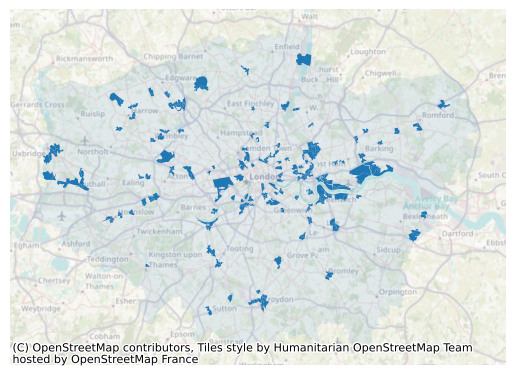

In [6]:
missing = imd19[imd19['imd19_score'].isnull()]
print(f"A total of {len(missing)} LSOAs from 2011 are missing in 2021 geographies "
      f"({round(len(missing)*100/len(imd19), 2)}%)")
ax = imd19[['geometry']].plot(linewidth=0, alpha=0.1)
missing.reset_index()[['geometry', 'LSOA21CD']].plot(ax=ax)
cx.add_basemap(ax, crs=imd19.crs, alpha=0.5)
ax.set_axis_off();

### 2025

In [7]:
imd25_src = pandas.read_csv('src_data/File_2_IoD2025 Domains of Deprivation.csv')

- Keep only the rank of IMD and LED, and join to geoms

In [8]:
imd25 = (
    lsoas
    .join((
        imd25_src
        .set_index('LSOA code (2021)')
        .rename(columns={
            'Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived)': 'imd25_rank',
            'Living Environment Rank (where 1 is most deprived)': 'led25_rank'
        })
        [['imd25_rank', 'led25_rank']]
    ), on='LSOA21CD')
)
imd25.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 4951 entries, 0 to 4950
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   LSOA21CD    4951 non-null   object  
 1   geometry    4951 non-null   geometry
 2   imd25_rank  4951 non-null   int64   
 3   led25_rank  4951 non-null   int64   
dtypes: geometry(1), int64(2), object(1)
memory usage: 154.8+ KB


### Joint IMD

In [9]:
imd = imd25.join(
    imd19.set_index('LSOA21CD')[['imd19_score', 'led19_score']], on='LSOA21CD'
)

## ML Split

Here we want to split the region into a number of blocks that we will assign to train/test to avoid excessive spatial leakage. We tag LSOAs with this for the modelling exercise later on.

In [10]:
import numpy as np
from shapely.geometry import box

def build_spatial_grid(lsoas, n_cells=50):
    """
    Partition a GeoDataFrame of LSOAs into a regular rectangular grid and
    return a Series mapping LSOA21CD -> block_id.

    n_cells controls the approximate total number of grid cells; cell size is
    derived from sqrt(bounding-box area / n_cells) so the grid scales with
    the extent of the input.
    """
    gdf = lsoas[['LSOA21CD', 'geometry']].to_crs(27700)
    minx, miny, maxx, maxy = gdf.total_bounds
    cell_size = np.sqrt((maxx - minx) * (maxy - miny) / n_cells)

    xs = np.arange(minx, maxx, cell_size)
    ys = np.arange(miny, maxy, cell_size)
    cells = [box(x, y, x + cell_size, y + cell_size) for x in xs for y in ys]

    grid = geopandas.GeoDataFrame(
        {'block_id': range(len(cells))}, geometry=cells, crs=27700
    )

    centroids = gdf.copy()
    centroids['geometry'] = centroids.geometry.centroid
    tagged = centroids.sjoin(grid[['block_id', 'geometry']], how='left', predicate='within')
    return tagged.set_index('LSOA21CD')['block_id']

grid_labels = build_spatial_grid(lsoas, n_cells=20)

- Explore the patterning

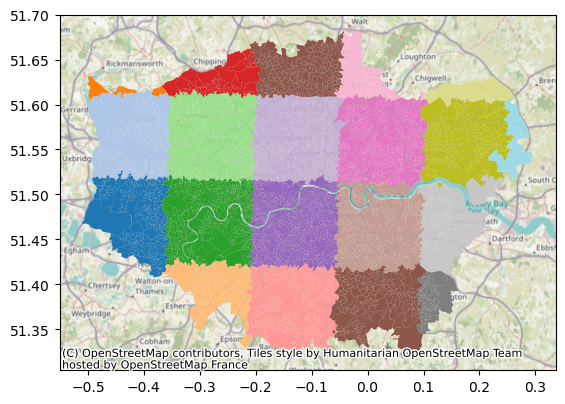

In [11]:
ax = (
    lsoas
    .set_index('LSOA21CD')
    .assign(grid_id=grid_labels)
).plot(column='grid_id', cmap='tab20')
cx.add_basemap(ax, crs=lsoas.crs)

- Manually assign a train/test label with 80/20 proportions

In [12]:
test = [10, 5, 12]
train_test = pandas.Series('train', index=grid_labels.index)
train_test[grid_labels.isin(test)] = 'test'

- Verify split

LSOAs in train: 75.42%


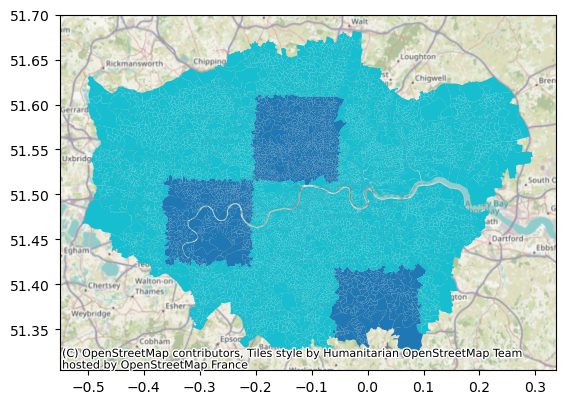

In [13]:
print(f"LSOAs in train: {round(len(train_test[train_test=='train'])*100/len(train_test), 2)}%")
ax = lsoas.set_index('LSOA21CD').assign(tt=train_test).plot(column='tt')
cx.add_basemap(ax, crs=lsoas.crs)

- Write it all into a single table

In [14]:
! rm imd.csv
(
    imd
    .set_index('LSOA21CD')
    .assign(grid_id=grid_labels)
    .assign(train_test=train_test)
    .reset_index()
    .drop(columns='geometry')
).to_csv('imd.csv')